In [1]:
!pip install cdsapi xarray netCDF4 numpy pandas matplotlib cartopy pillow
!pip install --upgrade cdsapi

# Import Pachages

In [5]:
import geopandas as gpd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import numpy as np
from shapely.geometry import Point
import matplotlib.colors as mcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cdsapi

# Connect Data Source

In [6]:
c = cdsapi.Client()
print("CDS API is working!")

2025-09-18 00:30:44,469 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-18 00:30:44,470 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


CDS API is working!


## Fetch Data

In [7]:
import cdsapi

dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": "reanalysis",
    "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
    "year": "2025",
    "month": "08",
    "day": [
        "25", "26", "27", "28", "29", "30"
    ],
    "time": [f"{h:02d}:00" for h in range(0, 24, 3)],
    "format": "netcdf",
    "area": [37.5, 68.7, 6.7, 97.25]
}

client = cdsapi.Client()

output_file = "I:\Planning\Geospatial Python\geopy environment\Practices\Wind Data Visualization\Data\wind_25to30Aug2025.nc"

client.retrieve(dataset, request, output_file)

print(f"Data successfully downloaded to {output_file}")

<>:20: SyntaxWarning: invalid escape sequence '\P'
<>:20: SyntaxWarning: invalid escape sequence '\P'
C:\Users\User\AppData\Local\Temp\ipykernel_1416\2972508895.py:20: SyntaxWarning: invalid escape sequence '\P'
  output_file = "I:\Planning\Geospatial Python\geopy environment\Practices\Wind Data Visualization\Data\wind_25to30Aug2025.nc"
2025-09-18 00:32:21,621 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-18 00:32:21,622 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-09-18 00:32:23,056 INFO Request ID is 0581f482-70f8-4dfc-9cfa-203551dbe5e2
2025-09-18 00:32:23,381 INFO status has been updated to accepted
2025-09-18 00:32:38,501 INFO status has been updated to running
2025-09-18 00:32:46,400 INFO status has been updated to successful


694a6da640e127e907811233e9f7a43a.nc:   0%|          | 0.00/3.19M [00:00<?, ?B/s]

Data successfully downloaded to I:\Planning\Geospatial Python\geopy environment\Practices\Wind Data Visualization\Data\wind_25to30Aug2025.nc


## Read AOI

In [8]:
bd = gpd.read_file("Data\Administrative areas (GADM) BD\BGD_adm0.shp")
bd = bd.to_crs(epsg=4326)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_1416\436697015.py:1: SyntaxWarning: invalid escape sequence '\A'
  bd = gpd.read_file("Data\Administrative areas (GADM) BD\BGD_adm0.shp")


## Select data and work on it

In [9]:
ds = xr.open_dataset("I:\Planning\Geospatial Python\geopy environment\Practices\Wind Data Visualization\Data\wind_25to30Aug2025.nc")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\User\AppData\Local\Temp\ipykernel_1416\2152805578.py:1: SyntaxWarning: invalid escape sequence '\P'
  ds = xr.open_dataset("I:\Planning\Geospatial Python\geopy environment\Practices\Wind Data Visualization\Data\wind_25to30Aug2025.nc")


In [11]:
u = ds['u10']
v = ds['v10']
lons = ds.longitude.values
lats = ds.latitude.values
times = ds.valid_time.values

lon2d, lat2d = np.meshgrid(lons, lats)
points = np.array([lon2d.flatten(), lat2d.flatten()]).T
points_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in points], crs="EPSG:4326")

inside = points_gdf.within(bd.unary_union)
mask = inside.values.reshape(lat2d.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_1416\3917738559.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  inside = points_gdf.within(bd.unary_union)


# Plot Data (Visualization) & Animate

✅ Wind streamline animation saved as GIF.


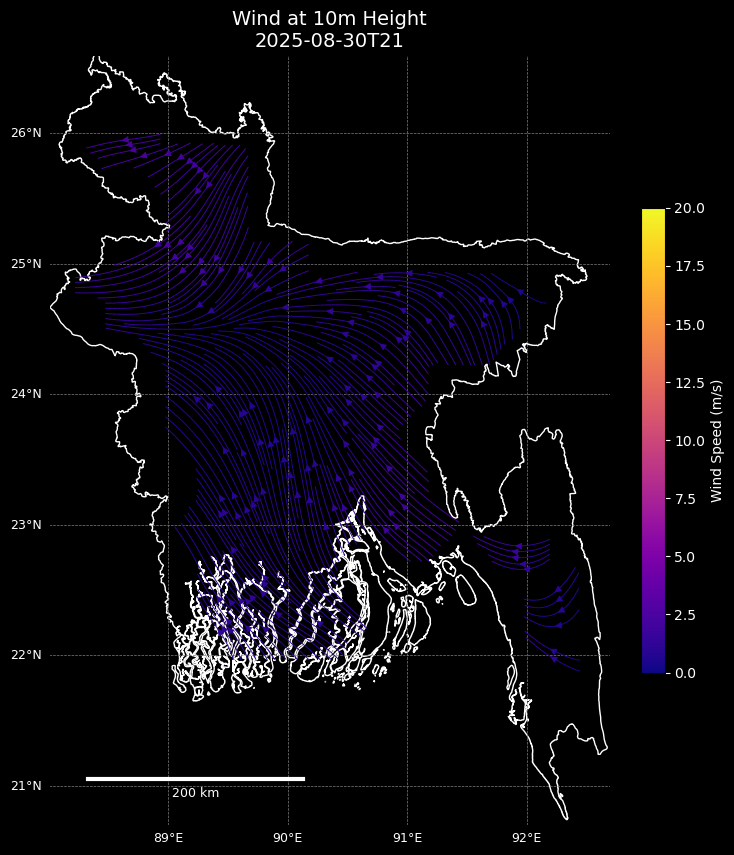

In [21]:
# --------------------------
# Map and figure setup
# --------------------------
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    facecolor='black'
)

# Set map extent for Bangladesh
ax.set_facecolor('black')
ax.set_extent([88.0, 92.7, 20.7, 26.6], crs=ccrs.PlateCarree())

# Plot Bangladesh boundary
bd.boundary.plot(ax=ax, edgecolor='white', linewidth=1)

# --------------------------
# Colorbar setup
# --------------------------
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=20)  # Adjust vmax according to wind speed range

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Wind Speed (m/s)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

# --------------------------
# Scale bar function
# --------------------------
def add_scalebar(ax, length_km=200, location=(0.05, 0.05), linewidth=3, text_color='white'):
    extent = ax.get_extent(ccrs.PlateCarree())
    lon_start = extent[0]
    lat_start = extent[2]
    lon_end = extent[1]
    lat_end = extent[3]

    km_per_deg = 111  # Approximate conversion
    length_deg = length_km / km_per_deg

    # Bar position
    bar_lon = lon_start + (lon_end - lon_start) * location[0]
    bar_lat = lat_start + (lat_end - lat_start) * location[1]

    # Draw the scale bar
    ax.plot(
        [bar_lon, bar_lon + length_deg], [bar_lat, bar_lat],
        transform=ccrs.PlateCarree(),
        color=text_color, linewidth=linewidth
    )

    # Place text slightly below the bar dynamically
    lat_offset = (lat_end - lat_start) * 0.01  # 1% of map height
    ax.text(
        bar_lon + length_deg / 2, bar_lat - lat_offset,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha='center', va='top',
        color=text_color, fontsize=9
    )

# --------------------------
# Animation function
# --------------------------
def animate(i):
    ax.clear()
    ax.set_facecolor('black')
    ax.set_extent([88.0, 92.7, 20.7, 26.6], crs=ccrs.PlateCarree())

    # Bangladesh boundary
    bd.boundary.plot(ax=ax, edgecolor='white', linewidth=1)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'color': 'white', 'fontsize': 9}
    gl.ylabel_style = {'color': 'white', 'fontsize': 9}

    # Wind data (replace u, v, mask, lon2d, lat2d, times with your arrays)
    u_data = u[i].values
    v_data = v[i].values
    u_masked = np.where(mask, u_data, np.nan)
    v_masked = np.where(mask, v_data, np.nan)
    wind_speed = np.sqrt(u_masked**2 + v_masked**2)

    ax.streamplot(
        lon2d, lat2d,
        u_masked, v_masked,
        transform=ccrs.PlateCarree(),
        color=wind_speed,
        cmap=cmap,
        norm=norm,
        linewidth=0.7,
        density=5
    )

    # Title
    ax.set_title(
        f"Wind at 10m Height\n{np.datetime_as_string(times[i], unit='h')}",
        fontsize=14,
        color='white'
    )

    # Add scale bar
    add_scalebar(ax, length_km=200, location=(0.07, 0.06), text_color='white')

# --------------------------
# Create animation
# --------------------------
anim = animation.FuncAnimation(fig, animate, frames=len(times), interval=500)

# Save GIF
output_path = r"I:\Planning\Geospatial Python\geopy environment\Practices\Wind Data Visualization\Bangladesh_Wind_Streamlines.gif"
anim.save(output_path, writer="pillow", dpi=900)

print("✅ Wind streamline animation saved as GIF.")
plt.show()

✓ Config file created at: /Users/satyamshah/.cdsapirc


2025-10-11 11:55:24,917 INFO Request ID is 5d3cb52a-e713-4e40-b803-6a1d9ad56c0a
2025-10-11 11:55:25,985 INFO status has been updated to accepted
2025-10-11 11:55:40,641 INFO status has been updated to successful


6ab59f6aa936e15f843abe9863209058.nc:   0%|          | 0.00/328k [00:00<?, ?B/s]

Data successfully downloaded to /Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc


/opt/anaconda3/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'gadm41_GBR_shp.zip': 'gadm41_GBR_0' (default), 'gadm41_GBR_1', 'gadm41_GBR_2', 'gadm41_GBR_3', 'gadm41_GBR_4'. Specify layer parameter to avoid this warning.
  result = read_func(


✓ UK boundary loaded
UK bounds: [-8.649996  49.86531    1.7643927 60.84548  ]

✓ Dataset loaded
Dataset info:
<xarray.Dataset> Size: 521kB
Dimensions:     (valid_time: 48, latitude: 41, longitude: 33)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 384B 2025-08-25 ... 2025-08-30T21...
  * latitude    (latitude) float64 328B 59.0 58.75 58.5 ... 49.5 49.25 49.0
  * longitude   (longitude) float64 264B -6.0 -5.75 -5.5 -5.25 ... 1.5 1.75 2.0
    number      int64 8B ...
    expver      (valid_time) <U4 768B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 260kB ...
    v10         (valid_time, latitude, longitude) float32 260kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-11T10:26 GRIB to

/var/folders/z0/pbnrrsld6yj0v10bgt7rnk900000gn/T/ipykernel_3223/2852315916.py:75: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  inside = points_gdf.within(uk.unary_union)


✓ Mask created - 490 points inside UK out of 1353 total

✓ Creating animation...
✓ Saving animation to /Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif...
Frame 0: 490 valid wind points
Frame 0: 490 valid wind points
Frame 1: 490 valid wind points
Frame 2: 490 valid wind points
Frame 3: 490 valid wind points
Frame 4: 490 valid wind points
Frame 5: 490 valid wind points
Frame 6: 490 valid wind points
Frame 7: 490 valid wind points
Frame 8: 490 valid wind points
Frame 9: 490 valid wind points
Frame 10: 490 valid wind points
Frame 11: 490 valid wind points
Frame 12: 490 valid wind points
Frame 13: 490 valid wind points
Frame 14: 490 valid wind points
Frame 15: 490 valid wind points
Frame 16: 490 valid wind points
Frame 17: 490 valid wind points
Frame 18: 490 valid wind points
Frame 19: 490 valid wind points
Frame 20: 490 valid wind points
Frame 21: 490 valid wind points
Frame 22: 490 valid wind points
Frame 23: 490 valid wind points
Frame 24: 490 valid wind points


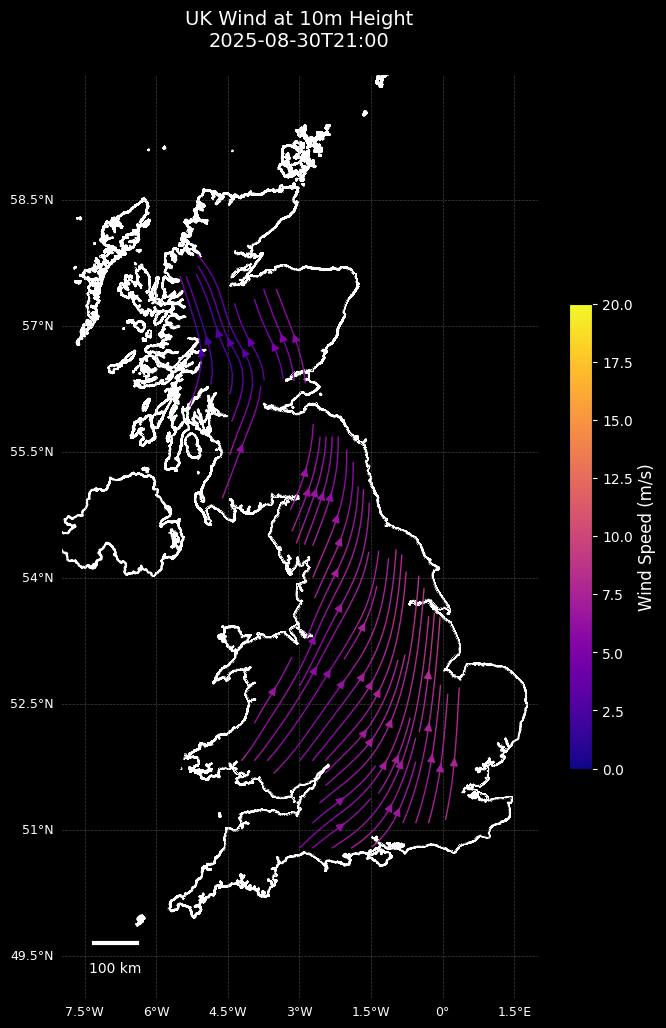

In [2]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import numpy as np
from shapely.geometry import Point
import matplotlib.colors as mcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cdsapi
import os

# Your CDS API credentials
cds_url = "https://cds.climate.copernicus.eu/api"
cds_key = "fdd8d6fd-b946-45aa-9b58-dbd1c289bfd9"

# Create the config file
config_file = os.path.expanduser("~/.cdsapirc")
with open(config_file, "w") as f:
    f.write(f"url: {cds_url}\n")
    f.write(f"key: {cds_key}\n")

print(f"✓ Config file created at: {config_file}")

# Download data
dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": "reanalysis",
    "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
    "year": "2025",
    "month": "08",
    "day": ["25", "26", "27", "28", "29", "30"],
    "time": [f"{h:02d}:00" for h in range(0, 24, 3)],
    "format": "netcdf",
    "area": [59, -6, 49, 2]  # UK area
}

client = cdsapi.Client()
output_file = "/Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc"

# Only download if file doesn't exist
if not os.path.exists(output_file):
    client.retrieve(dataset, request, output_file)
    print(f"Data successfully downloaded to {output_file}")
else:
    print(f"Using existing file: {output_file}")

# Load UK boundary
uk = gpd.read_file("https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip")
uk = uk.to_crs(epsg=4326)
print("✓ UK boundary loaded")
print(f"UK bounds: {uk.total_bounds}")

# Load wind data
ds = xr.open_dataset(output_file)
print("\n✓ Dataset loaded")
print(f"Dataset info:\n{ds}")

u = ds['u10']
v = ds['v10']
lons = ds.longitude.values
lats = ds.latitude.values
times = ds.valid_time.values

print(f"\nLon range: {lons.min()} to {lons.max()}")
print(f"Lat range: {lats.min()} to {lats.max()}")
print(f"Number of time steps: {len(times)}")

# Create mask for UK
lon2d, lat2d = np.meshgrid(lons, lats)
points = np.array([lon2d.flatten(), lat2d.flatten()]).T
points_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in points], crs="EPSG:4326")

inside = points_gdf.within(uk.unary_union)
mask = inside.values.reshape(lat2d.shape)
print(f"✓ Mask created - {mask.sum()} points inside UK out of {mask.size} total")

# UK extent (corrected from Bangladesh coordinates!)
uk_extent = [-8, 2, 49, 60]  # [West, East, South, North]

# Map and figure setup
fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
    facecolor='black'
)

ax.set_facecolor('black')
ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

# Colorbar setup
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Wind Speed (m/s)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

# Scale bar function
def add_scalebar(ax, length_km=100, location=(0.05, 0.05), linewidth=3, text_color='white'):
    extent = ax.get_extent(ccrs.PlateCarree())
    lon_start = extent[0]
    lat_start = extent[2]
    lon_end = extent[1]
    lat_end = extent[3]

    km_per_deg = 111
    length_deg = length_km / km_per_deg

    bar_lon = lon_start + (lon_end - lon_start) * location[0]
    bar_lat = lat_start + (lat_end - lat_start) * location[1]

    ax.plot(
        [bar_lon, bar_lon + length_deg], [bar_lat, bar_lat],
        transform=ccrs.PlateCarree(),
        color=text_color, linewidth=linewidth
    )

    lat_offset = (lat_end - lat_start) * 0.02
    ax.text(
        bar_lon + length_deg / 2, bar_lat - lat_offset,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha='center', va='top',
        color=text_color, fontsize=10
    )

# Animation function
def animate(i):
    ax.clear()
    ax.set_facecolor('black')
    ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

    # UK boundary
    uk.boundary.plot(ax=ax, edgecolor='white', linewidth=1.5, transform=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'color': 'white', 'fontsize': 9}
    gl.ylabel_style = {'color': 'white', 'fontsize': 9}

    # Wind data
    u_data = u[i].values
    v_data = v[i].values
    
    # Option 1: Use mask (only shows wind inside UK boundary)
    u_masked = np.where(mask, u_data, np.nan)
    v_masked = np.where(mask, v_data, np.nan)
    
    # Option 2: Show all wind data (uncomment these lines and comment lines above)
    # u_masked = u_data
    # v_masked = v_data
    
    wind_speed = np.sqrt(u_masked**2 + v_masked**2)

    # Check if we have valid data
    valid_points = np.sum(~np.isnan(wind_speed))
    print(f"Frame {i}: {valid_points} valid wind points")

    if valid_points > 10:  # Only plot if we have enough data
        ax.streamplot(
            lon2d, lat2d,
            u_masked, v_masked,
            transform=ccrs.PlateCarree(),
            color=wind_speed,
            cmap=cmap,
            norm=norm,
            linewidth=1.0,
            density=2.5,
            arrowsize=1.2
        )

    # Title
    time_str = str(times[i])[:16]  # Format timestamp
    ax.set_title(
        f"UK Wind at 10m Height\n{time_str}",
        fontsize=14,
        color='white',
        pad=20
    )

    # Add scale bar
    add_scalebar(ax, length_km=100, location=(0.07, 0.06), text_color='white')

# Create animation
print("\n✓ Creating animation...")
anim = animation.FuncAnimation(fig, animate, frames=len(times), interval=500, repeat=True)

# Save GIF
output_path = r"/Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif"
print(f"✓ Saving animation to {output_path}...")
anim.save(output_path, writer="pillow", dpi=150)  # Reduced dpi from 900 for faster processing

print("✅ Wind streamline animation saved as GIF.")
plt.show()

✓ Config file created at: /Users/satyamshah/.cdsapirc
Using existing file: /Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc


/opt/anaconda3/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'gadm41_GBR_shp.zip': 'gadm41_GBR_0' (default), 'gadm41_GBR_1', 'gadm41_GBR_2', 'gadm41_GBR_3', 'gadm41_GBR_4'. Specify layer parameter to avoid this warning.
  result = read_func(


✓ UK boundary loaded
UK bounds: [-8.649996  49.86531    1.7643927 60.84548  ]

✓ Dataset loaded
Dataset info:
<xarray.Dataset> Size: 521kB
Dimensions:     (valid_time: 48, latitude: 41, longitude: 33)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 384B 2025-08-25 ... 2025-08-30T21...
  * latitude    (latitude) float64 328B 59.0 58.75 58.5 ... 49.5 49.25 49.0
  * longitude   (longitude) float64 264B -6.0 -5.75 -5.5 -5.25 ... 1.5 1.75 2.0
    number      int64 8B ...
    expver      (valid_time) <U4 768B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 260kB ...
    v10         (valid_time, latitude, longitude) float32 260kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-11T10:26 GRIB to

/var/folders/z0/pbnrrsld6yj0v10bgt7rnk900000gn/T/ipykernel_3223/97076941.py:75: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  inside = points_gdf.within(uk.unary_union)


✓ Mask created - 490 points inside UK out of 1353 total

✓ Creating animation...
✓ Saving animation to /Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif...
Frame 0: 1353 valid wind points
Frame 0: 1353 valid wind points
Frame 1: 1353 valid wind points
Frame 2: 1353 valid wind points
Frame 3: 1353 valid wind points
Frame 4: 1353 valid wind points
Frame 5: 1353 valid wind points
Frame 6: 1353 valid wind points
Frame 7: 1353 valid wind points
Frame 8: 1353 valid wind points
Frame 9: 1353 valid wind points
Frame 10: 1353 valid wind points
Frame 11: 1353 valid wind points
Frame 12: 1353 valid wind points
Frame 13: 1353 valid wind points
Frame 14: 1353 valid wind points
Frame 15: 1353 valid wind points
Frame 16: 1353 valid wind points
Frame 17: 1353 valid wind points
Frame 18: 1353 valid wind points
Frame 19: 1353 valid wind points
Frame 20: 1353 valid wind points
Frame 21: 1353 valid wind points
Frame 22: 1353 valid wind points
Frame 23: 1353 valid wind points
Frame 2

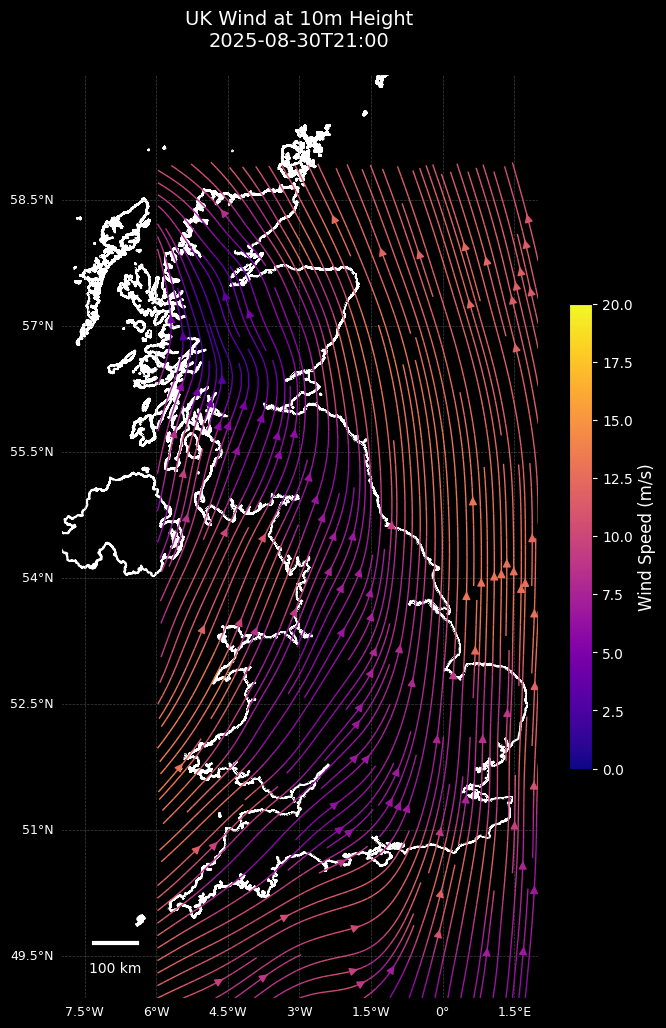

In [3]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import numpy as np
from shapely.geometry import Point
import matplotlib.colors as mcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cdsapi
import os

# Your CDS API credentials
cds_url = "https://cds.climate.copernicus.eu/api"
cds_key = "fdd8d6fd-b946-45aa-9b58-dbd1c289bfd9"

# Create the config file
config_file = os.path.expanduser("~/.cdsapirc")
with open(config_file, "w") as f:
    f.write(f"url: {cds_url}\n")
    f.write(f"key: {cds_key}\n")

print(f"✓ Config file created at: {config_file}")

# Download data
dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": "reanalysis",
    "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
    "year": "2025",
    "month": "08",
    "day": ["25", "26", "27", "28", "29", "30"],
    "time": [f"{h:02d}:00" for h in range(0, 24, 3)],
    "format": "netcdf",
    "area": [59, -6, 49, 2]  # UK area
}

client = cdsapi.Client()
output_file = "/Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc"

# Only download if file doesn't exist
if not os.path.exists(output_file):
    client.retrieve(dataset, request, output_file)
    print(f"Data successfully downloaded to {output_file}")
else:
    print(f"Using existing file: {output_file}")

# Load UK boundary
uk = gpd.read_file("https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip")
uk = uk.to_crs(epsg=4326)
print("✓ UK boundary loaded")
print(f"UK bounds: {uk.total_bounds}")

# Load wind data
ds = xr.open_dataset(output_file)
print("\n✓ Dataset loaded")
print(f"Dataset info:\n{ds}")

u = ds['u10']
v = ds['v10']
lons = ds.longitude.values
lats = ds.latitude.values
times = ds.valid_time.values

print(f"\nLon range: {lons.min()} to {lons.max()}")
print(f"Lat range: {lats.min()} to {lats.max()}")
print(f"Number of time steps: {len(times)}")

# Create mask for UK
lon2d, lat2d = np.meshgrid(lons, lats)
points = np.array([lon2d.flatten(), lat2d.flatten()]).T
points_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in points], crs="EPSG:4326")

inside = points_gdf.within(uk.unary_union)
mask = inside.values.reshape(lat2d.shape)
print(f"✓ Mask created - {mask.sum()} points inside UK out of {mask.size} total")

# UK extent (corrected from Bangladesh coordinates!)
uk_extent = [-8, 2, 49, 60]  # [West, East, South, North]

# Map and figure setup
fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
    facecolor='black'
)

ax.set_facecolor('black')
ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

# Colorbar setup
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Wind Speed (m/s)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

# Scale bar function
def add_scalebar(ax, length_km=100, location=(0.05, 0.05), linewidth=3, text_color='white'):
    extent = ax.get_extent(ccrs.PlateCarree())
    lon_start = extent[0]
    lat_start = extent[2]
    lon_end = extent[1]
    lat_end = extent[3]

    km_per_deg = 111
    length_deg = length_km / km_per_deg

    bar_lon = lon_start + (lon_end - lon_start) * location[0]
    bar_lat = lat_start + (lat_end - lat_start) * location[1]

    ax.plot(
        [bar_lon, bar_lon + length_deg], [bar_lat, bar_lat],
        transform=ccrs.PlateCarree(),
        color=text_color, linewidth=linewidth
    )

    lat_offset = (lat_end - lat_start) * 0.02
    ax.text(
        bar_lon + length_deg / 2, bar_lat - lat_offset,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha='center', va='top',
        color=text_color, fontsize=10
    )

# Animation function
def animate(i):
    ax.clear()
    ax.set_facecolor('black')
    ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

    # UK boundary
    uk.boundary.plot(ax=ax, edgecolor='white', linewidth=1.5, transform=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'color': 'white', 'fontsize': 9}
    gl.ylabel_style = {'color': 'white', 'fontsize': 9}

    # Wind data
    u_data = u[i].values
    v_data = v[i].values
    
    # Show all wind data (not masked)
    u_masked = u_data
    v_masked = v_data
    
    wind_speed = np.sqrt(u_masked**2 + v_masked**2)

    # Check if we have valid data
    valid_points = np.sum(~np.isnan(wind_speed))
    print(f"Frame {i}: {valid_points} valid wind points")

    if valid_points > 10:  # Only plot if we have enough data
        ax.streamplot(
            lon2d, lat2d,
            u_masked, v_masked,
            transform=ccrs.PlateCarree(),
            color=wind_speed,
            cmap=cmap,
            norm=norm,
            linewidth=1.0,
            density=2.5,
            arrowsize=1.2
        )

    # Title
    time_str = str(times[i])[:16]  # Format timestamp
    ax.set_title(
        f"UK Wind at 10m Height\n{time_str}",
        fontsize=14,
        color='white',
        pad=20
    )

    # Add scale bar
    add_scalebar(ax, length_km=100, location=(0.07, 0.06), text_color='white')

# Create animation
print("\n✓ Creating animation...")
anim = animation.FuncAnimation(fig, animate, frames=len(times), interval=500, repeat=True)

# Save GIF
output_path = r"/Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif"
print(f"✓ Saving animation to {output_path}...")
anim.save(output_path, writer="pillow", dpi=150)  # Reduced dpi from 900 for faster processing

print("✅ Wind streamline animation saved as GIF.")
plt.show()

✓ Config file created at: /Users/satyamshah/.cdsapirc
Using existing file: /Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc


/opt/anaconda3/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'gadm41_GBR_shp.zip': 'gadm41_GBR_0' (default), 'gadm41_GBR_1', 'gadm41_GBR_2', 'gadm41_GBR_3', 'gadm41_GBR_4'. Specify layer parameter to avoid this warning.
  result = read_func(
/var/folders/z0/pbnrrsld6yj0v10bgt7rnk900000gn/T/ipykernel_3223/867798420.py:75: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  inside = points_gdf.within(uk.unary_union)


✓ UK boundary loaded
UK bounds: [-8.649996  49.86531    1.7643927 60.84548  ]

✓ Dataset loaded
Dataset info:
<xarray.Dataset> Size: 521kB
Dimensions:     (valid_time: 48, latitude: 41, longitude: 33)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 384B 2025-08-25 ... 2025-08-30T21...
  * latitude    (latitude) float64 328B 59.0 58.75 58.5 ... 49.5 49.25 49.0
  * longitude   (longitude) float64 264B -6.0 -5.75 -5.5 -5.25 ... 1.5 1.75 2.0
    number      int64 8B ...
    expver      (valid_time) <U4 768B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 260kB ...
    v10         (valid_time, latitude, longitude) float32 260kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-11T10:26 GRIB to

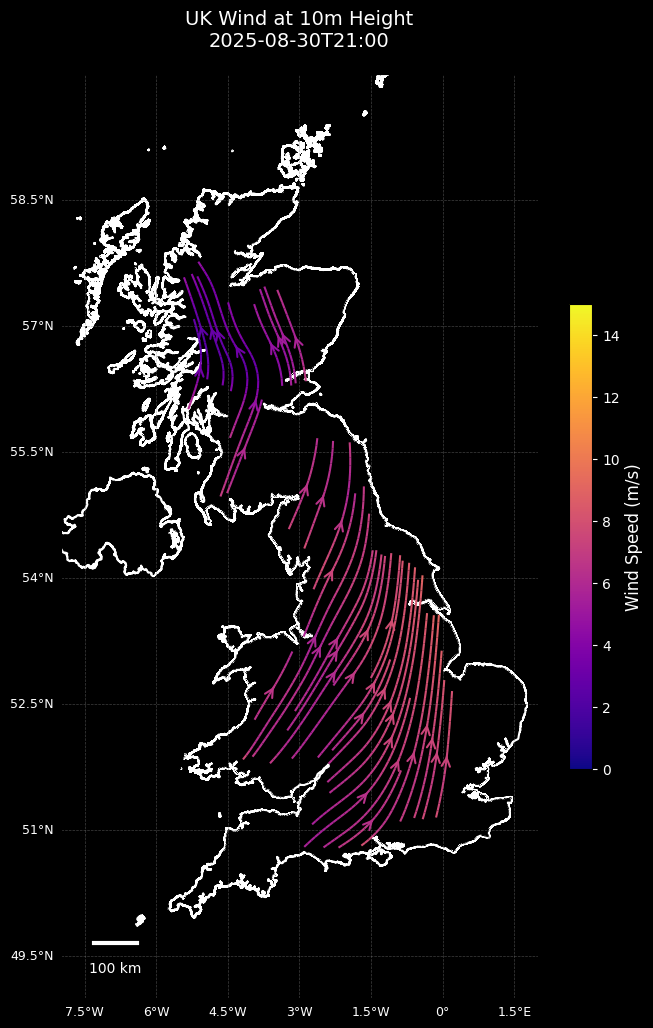

In [4]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import numpy as np
from shapely.geometry import Point
import matplotlib.colors as mcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cdsapi
import os

# Your CDS API credentials
cds_url = "https://cds.climate.copernicus.eu/api"
cds_key = "fdd8d6fd-b946-45aa-9b58-dbd1c289bfd9"

# Create the config file
config_file = os.path.expanduser("~/.cdsapirc")
with open(config_file, "w") as f:
    f.write(f"url: {cds_url}\n")
    f.write(f"key: {cds_key}\n")

print(f"✓ Config file created at: {config_file}")

# Download data
dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": "reanalysis",
    "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
    "year": "2025",
    "month": "08",
    "day": ["25", "26", "27", "28", "29", "30"],
    "time": [f"{h:02d}:00" for h in range(0, 24, 3)],
    "format": "netcdf",
    "area": [59, -6, 49, 2]  # UK area
}

client = cdsapi.Client()
output_file = "/Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc"

# Only download if file doesn't exist
if not os.path.exists(output_file):
    client.retrieve(dataset, request, output_file)
    print(f"Data successfully downloaded to {output_file}")
else:
    print(f"Using existing file: {output_file}")

# Load UK boundary
uk = gpd.read_file("https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip")
uk = uk.to_crs(epsg=4326)
print("✓ UK boundary loaded")
print(f"UK bounds: {uk.total_bounds}")

# Load wind data
ds = xr.open_dataset(output_file)
print("\n✓ Dataset loaded")
print(f"Dataset info:\n{ds}")

u = ds['u10']
v = ds['v10']
lons = ds.longitude.values
lats = ds.latitude.values
times = ds.valid_time.values

print(f"\nLon range: {lons.min()} to {lons.max()}")
print(f"Lat range: {lats.min()} to {lats.max()}")
print(f"Number of time steps: {len(times)}")

# Create mask for UK
lon2d, lat2d = np.meshgrid(lons, lats)
points = np.array([lon2d.flatten(), lat2d.flatten()]).T
points_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in points], crs="EPSG:4326")

inside = points_gdf.within(uk.unary_union)
mask = inside.values.reshape(lat2d.shape)
print(f"✓ Mask created - {mask.sum()} points inside UK out of {mask.size} total")

# UK extent (corrected from Bangladesh coordinates!)
uk_extent = [-8, 2, 49, 60]  # [West, East, South, North]

# Map and figure setup
fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
    facecolor='black'
)

ax.set_facecolor('black')
ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

# Colorbar setup
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=15)  # Adjusted range

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Wind Speed (m/s)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

# Scale bar function
def add_scalebar(ax, length_km=100, location=(0.05, 0.05), linewidth=3, text_color='white'):
    extent = ax.get_extent(ccrs.PlateCarree())
    lon_start = extent[0]
    lat_start = extent[2]
    lon_end = extent[1]
    lat_end = extent[3]

    km_per_deg = 111
    length_deg = length_km / km_per_deg

    bar_lon = lon_start + (lon_end - lon_start) * location[0]
    bar_lat = lat_start + (lat_end - lat_start) * location[1]

    ax.plot(
        [bar_lon, bar_lon + length_deg], [bar_lat, bar_lat],
        transform=ccrs.PlateCarree(),
        color=text_color, linewidth=linewidth
    )

    lat_offset = (lat_end - lat_start) * 0.02
    ax.text(
        bar_lon + length_deg / 2, bar_lat - lat_offset,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha='center', va='top',
        color=text_color, fontsize=10
    )

# Animation function
def animate(i):
    ax.clear()
    ax.set_facecolor('black')
    ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

    # UK boundary
    uk.boundary.plot(ax=ax, edgecolor='white', linewidth=1.5, transform=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'color': 'white', 'fontsize': 9}
    gl.ylabel_style = {'color': 'white', 'fontsize': 9}

    # Wind data
    u_data = u[i].values
    v_data = v[i].values
    
    # Apply mask to show wind only inside UK
    u_masked = np.where(mask, u_data, np.nan)
    v_masked = np.where(mask, v_data, np.nan)
    
    wind_speed = np.sqrt(u_masked**2 + v_masked**2)

    # Check if we have valid data
    valid_points = np.sum(~np.isnan(wind_speed))
    print(f"Frame {i}: {valid_points} valid wind points")

    if valid_points > 10:  # Only plot if we have enough data
        # Add some randomness to starting points for more organic look
        seed_points = np.random.RandomState(42).rand(500, 2)
        seed_points[:, 0] = seed_points[:, 0] * (lons.max() - lons.min()) + lons.min()
        seed_points[:, 1] = seed_points[:, 1] * (lats.max() - lats.min()) + lats.min()
        
        ax.streamplot(
            lon2d, lat2d,
            u_masked, v_masked,
            transform=ccrs.PlateCarree(),
            color=wind_speed,
            cmap=cmap,
            norm=norm,
            linewidth=1.5,
            density=[4, 3],
            arrowsize=1.5,
            arrowstyle='->',
            minlength=0.1,
            start_points=seed_points
        )

    # Title
    time_str = str(times[i])[:16]  # Format timestamp
    ax.set_title(
        f"UK Wind at 10m Height\n{time_str}",
        fontsize=14,
        color='white',
        pad=20
    )

    # Add scale bar
    add_scalebar(ax, length_km=100, location=(0.07, 0.06), text_color='white')

# Create animation
print("\n✓ Creating animation...")
anim = animation.FuncAnimation(fig, animate, frames=len(times), interval=500, repeat=True)

# Save GIF
output_path = r"/Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif"
print(f"✓ Saving animation to {output_path}...")
anim.save(output_path, writer="pillow", dpi=600)  # High quality output

print("✅ Wind streamline animation saved as GIF.")
plt.show()

✓ Config file created at: /Users/satyamshah/.cdsapirc
Using existing file: /Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc


/opt/anaconda3/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'gadm41_GBR_shp.zip': 'gadm41_GBR_0' (default), 'gadm41_GBR_1', 'gadm41_GBR_2', 'gadm41_GBR_3', 'gadm41_GBR_4'. Specify layer parameter to avoid this warning.
  result = read_func(


✓ UK boundary loaded
UK bounds: [-8.649996  49.86531    1.7643927 60.84548  ]

✓ Dataset loaded
Dataset info:
<xarray.Dataset> Size: 521kB
Dimensions:     (valid_time: 48, latitude: 41, longitude: 33)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 384B 2025-08-25 ... 2025-08-30T21...
  * latitude    (latitude) float64 328B 59.0 58.75 58.5 ... 49.5 49.25 49.0
  * longitude   (longitude) float64 264B -6.0 -5.75 -5.5 -5.25 ... 1.5 1.75 2.0
    number      int64 8B ...
    expver      (valid_time) <U4 768B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 260kB ...
    v10         (valid_time, latitude, longitude) float32 260kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-11T10:26 GRIB to

/var/folders/z0/pbnrrsld6yj0v10bgt7rnk900000gn/T/ipykernel_3223/1474544934.py:75: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  inside = points_gdf.within(uk.unary_union)


✓ Mask created - 490 points inside UK out of 1353 total

✓ Creating animation...
✓ Saving animation to /Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif...
Frame 0: 490 valid wind points
Frame 0: 490 valid wind points
Frame 1: 490 valid wind points
Frame 2: 490 valid wind points
Frame 3: 490 valid wind points
Frame 4: 490 valid wind points
Frame 5: 490 valid wind points
Frame 6: 490 valid wind points
Frame 7: 490 valid wind points
Frame 8: 490 valid wind points
Frame 9: 490 valid wind points
Frame 10: 490 valid wind points
Frame 11: 490 valid wind points
Frame 12: 490 valid wind points
Frame 13: 490 valid wind points
Frame 14: 490 valid wind points
Frame 15: 490 valid wind points
Frame 16: 490 valid wind points
Frame 17: 490 valid wind points
Frame 18: 490 valid wind points
Frame 19: 490 valid wind points
Frame 20: 490 valid wind points
Frame 21: 490 valid wind points
Frame 22: 490 valid wind points
Frame 23: 490 valid wind points
Frame 24: 490 valid wind points


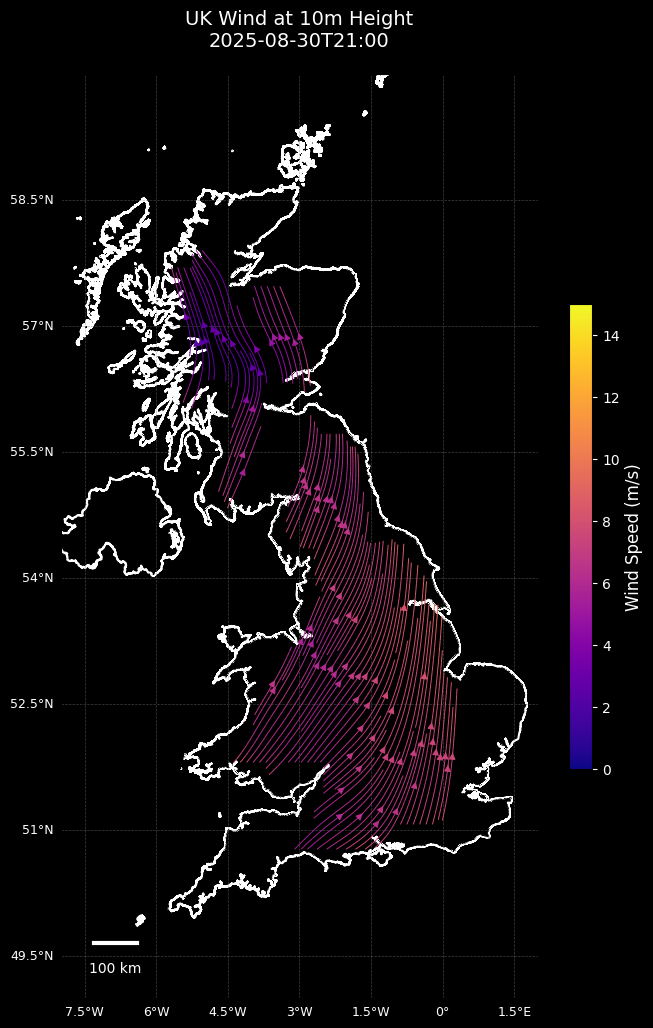

In [5]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import numpy as np
from shapely.geometry import Point
import matplotlib.colors as mcolors
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cdsapi
import os

# Your CDS API credentials
cds_url = "https://cds.climate.copernicus.eu/api"
cds_key = "fdd8d6fd-b946-45aa-9b58-dbd1c289bfd9"

# Create the config file
config_file = os.path.expanduser("~/.cdsapirc")
with open(config_file, "w") as f:
    f.write(f"url: {cds_url}\n")
    f.write(f"key: {cds_key}\n")

print(f"✓ Config file created at: {config_file}")

# Download data
dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": "reanalysis",
    "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
    "year": "2025",
    "month": "08",
    "day": ["25", "26", "27", "28", "29", "30"],
    "time": [f"{h:02d}:00" for h in range(0, 24, 3)],
    "format": "netcdf",
    "area": [59, -6, 49, 2]  # UK area
}

client = cdsapi.Client()
output_file = "/Users/satyamshah/Downloads/ Automated wind flow map of UK/uk_wind_data.nc"

# Only download if file doesn't exist
if not os.path.exists(output_file):
    client.retrieve(dataset, request, output_file)
    print(f"Data successfully downloaded to {output_file}")
else:
    print(f"Using existing file: {output_file}")

# Load UK boundary
uk = gpd.read_file("https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip")
uk = uk.to_crs(epsg=4326)
print("✓ UK boundary loaded")
print(f"UK bounds: {uk.total_bounds}")

# Load wind data
ds = xr.open_dataset(output_file)
print("\n✓ Dataset loaded")
print(f"Dataset info:\n{ds}")

u = ds['u10']
v = ds['v10']
lons = ds.longitude.values
lats = ds.latitude.values
times = ds.valid_time.values

print(f"\nLon range: {lons.min()} to {lons.max()}")
print(f"Lat range: {lats.min()} to {lats.max()}")
print(f"Number of time steps: {len(times)}")

# Create mask for UK
lon2d, lat2d = np.meshgrid(lons, lats)
points = np.array([lon2d.flatten(), lat2d.flatten()]).T
points_gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in points], crs="EPSG:4326")

inside = points_gdf.within(uk.unary_union)
mask = inside.values.reshape(lat2d.shape)
print(f"✓ Mask created - {mask.sum()} points inside UK out of {mask.size} total")

# UK extent (corrected from Bangladesh coordinates!)
uk_extent = [-8, 2, 49, 60]  # [West, East, South, North]

# Map and figure setup
fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
    facecolor='black'
)

ax.set_facecolor('black')
ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

# Colorbar setup
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=15)  # Adjusted range

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Wind Speed (m/s)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

# Scale bar function
def add_scalebar(ax, length_km=100, location=(0.05, 0.05), linewidth=3, text_color='white'):
    extent = ax.get_extent(ccrs.PlateCarree())
    lon_start = extent[0]
    lat_start = extent[2]
    lon_end = extent[1]
    lat_end = extent[3]

    km_per_deg = 111
    length_deg = length_km / km_per_deg

    bar_lon = lon_start + (lon_end - lon_start) * location[0]
    bar_lat = lat_start + (lat_end - lat_start) * location[1]

    ax.plot(
        [bar_lon, bar_lon + length_deg], [bar_lat, bar_lat],
        transform=ccrs.PlateCarree(),
        color=text_color, linewidth=linewidth
    )

    lat_offset = (lat_end - lat_start) * 0.02
    ax.text(
        bar_lon + length_deg / 2, bar_lat - lat_offset,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha='center', va='top',
        color=text_color, fontsize=10
    )

# Animation function
def animate(i):
    ax.clear()
    ax.set_facecolor('black')
    ax.set_extent(uk_extent, crs=ccrs.PlateCarree())

    # UK boundary
    uk.boundary.plot(ax=ax, edgecolor='white', linewidth=1.5, transform=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'color': 'white', 'fontsize': 9}
    gl.ylabel_style = {'color': 'white', 'fontsize': 9}

    # Wind data
    u_data = u[i].values
    v_data = v[i].values
    
    # Apply mask to show wind only inside UK
    u_masked = np.where(mask, u_data, np.nan)
    v_masked = np.where(mask, v_data, np.nan)
    
    wind_speed = np.sqrt(u_masked**2 + v_masked**2)

    # Check if we have valid data
    valid_points = np.sum(~np.isnan(wind_speed))
    print(f"Frame {i}: {valid_points} valid wind points")

    if valid_points > 10:  # Only plot if we have enough data
        ax.streamplot(
            lon2d, lat2d,
            u_masked, v_masked,
            transform=ccrs.PlateCarree(),
            color=wind_speed,
            cmap=cmap,
            norm=norm,
            linewidth=0.7,
            density=5
        )

    # Title
    time_str = str(times[i])[:16]  # Format timestamp
    ax.set_title(
        f"UK Wind at 10m Height\n{time_str}",
        fontsize=14,
        color='white',
        pad=20
    )

    # Add scale bar
    add_scalebar(ax, length_km=100, location=(0.07, 0.06), text_color='white')

# Create animation
print("\n✓ Creating animation...")
anim = animation.FuncAnimation(fig, animate, frames=len(times), interval=500, repeat=True)

# Save GIF
output_path = r"/Users/satyamshah/Downloads/ Automated wind flow map of UK/UKWindMap.gif"
print(f"✓ Saving animation to {output_path}...")
anim.save(output_path, writer="pillow", dpi=900)  # Match reference quality

print("✅ Wind streamline animation saved as GIF.")
plt.show()